
# Implicitation Study: Analysis of the 7 Core German Adjectives
### (gut, wichtig, glücklich, richtig, falsch, schlecht, verschieden)

This notebook analyses the special **implicitation dataset**: sentences where an English
source adjective was translated into German using one of the 7 core adjectives, but the
source adjective is generally **not** the "default" one-to-one equivalent of that German word
(e.g. not *important → wichtig*, but *essential → wichtig*; not *good → gut*, but *great → gut*).

The idea behind this special dataset is to zoom in on cases where a translator chose a more
general/basic evaluative German adjective for a more specific English one — a pattern that,
when it shifts the evaluative meaning, is coded here as **implicitation** (or, less often,
**explicitation**).

**Data**: 7 Excel files (one per adjective), each containing token-level annotations:
domain, gender of speaker, the English sentence/lemma, the aligned German sentence/lemma,
evaluativity and attitude-type coding (Appreciation / Judgement / Affect, following an
Appraisal-style framework) for both languages, and two translation-shift columns:
`Translation_strategy` (Equivalence vs. Alteration) and `Translationese_effect`
(Implicitation / Explicitation, coded only when the meaning shifted).

**What this notebook does, task by task:**
1. Load & combine the 7 files into one working dataset
2. Data cleaning — remove rows where the source lemma is the *default* one-to-one equivalent
   of the target adjective (e.g. *different → verschieden*), since those don't belong in an
   implicitation-focused dataset
3. Overview of the (cleaned) sample (size, domains, speaker gender)
4. Domain and speaker-gender distribution
5. Which English adjectives get "levelled" into each German core adjective
6. Translation strategy (Equivalence vs. Alteration) per adjective
7. Translationese effect — the key variable — frequency & proportions per adjective
8. How strategy and effect relate to each other
9. Whether evaluative meaning is preserved or lost across EN → DE
10. Whether the *type* of attitude (Appreciation/Judgement/Affect) shifts, and how implicitation relates to attitude type
11. Domain-wise implicitation rates
12. Gender-wise implicitation rates
13. Export of summary tables (for reporting / for the write-up)
14–20. Comparison against the **normal** (non-implicitation) dataset of the same 7 adjectives
   (17 English source adjectives, of which 7 are the direct equivalents of our core adjectives)

Run all cells top to bottom. All output tables are also written to `/mnt/user-data/outputs/`
as CSV files so they can be reused in the final write-up.



## 0. Setup

Import the libraries we need and set a consistent, readable plotting style. We also define
the list of the 7 target adjectives (this fixes the order they appear in throughout all
charts and tables) and a lookup of what each adjective's "default"/expected one-to-one
English equivalent would be — we'll use that lookup in Task 4 as a sanity check.


In [2]:
!unzip "German translations - data for implicitation study-20260719T193636Z-1-001.zip"

Archive:  German translations - data for implicitation study-20260719T193636Z-1-001.zip
  inflating: German translations - data for implicitation study/verschieden_Bianca.xlsx  
  inflating: German translations - data for implicitation study/falsch_Bianca.xlsx  
  inflating: German translations - data for implicitation study/wichtig_Bianca.xlsx  
  inflating: German translations - data for implicitation study/richtig_Bianca.xlsx  
  inflating: German translations - data for implicitation study/glücklich_Bianca.xlsx  
  inflating: German translations - data for implicitation study/gut_Bianca.xlsx  
  inflating: German translations - data for implicitation study/schlecht_Bianca.xlsx  


In [3]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Folder containing the 7 Excel files (ships alongside this notebook)
DATA_DIR = "German translations - data for implicitation study"

# Fixed order used throughout the notebook (matches the 7 core adjectives of the wider project)
TARGET_ADJECTIVES = ["gut", "wichtig", "glücklich", "richtig", "falsch", "schlecht", "verschieden"]

# The "default"/expected one-to-one English equivalent of each German core adjective.
# Used only as a sanity check in Task 4 — this implicitation dataset is specifically meant
# to EXCLUDE these default pairs (e.g. we expect "great -> gut", not "good -> gut").
DEFAULT_EQUIVALENT = {
    "gut": "good",
    "wichtig": "important",
    "glücklich": "happy",
    "richtig": "right",
    "falsch": "wrong",
    "schlecht": "bad",
    "verschieden": "different",
}

OUTPUT_DIR = "/mnt/user-data/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)



## 1. Load and combine the 7 files

Each Excel file corresponds to one target adjective and has an identical column structure.
We load all 7, tag every row with which target adjective it belongs to (`target_adjective`),
and concatenate them into a single working DataFrame (`df`). This combined table is what the
rest of the notebook works from.


In [4]:

frames = []
for adj in TARGET_ADJECTIVES:
    path = os.path.join(DATA_DIR, f"{adj}_Bianca.xlsx")
    d = pd.read_excel(path)
    d["target_adjective"] = adj
    frames.append(d)

df = pd.concat(frames, ignore_index=True)

print(f"Combined dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Combined dataset: 489 rows, 18 columns


,file,Domain,Gender,sent_index,token_id,token_form,token_lemma,sentence,EN_Evaluative?,EN_Attitude_type,de_aligned_forms,de_aligned_lemmas,de_sentence,DE_Evaluative?,DE_Attitude_type,Translation_strategy,Translationese_effect,target_adjective
0,Art11_en.conllu,Art,M,92,17,greatest,great,"I kept making comics , and at the Worcester Ar...",Evaluative,Appreciation,besten,gut,"Ich machte weiter Comics , und in dem Worceste...",Evaluative,Appreciation,NaN,NaN,gut
1,Art11_en.conllu,Art,M,93,14,dear,dear,"Mark Lynch , he 's an amazing teacher and he '...",Non-evaluative,NaN,guter,gut,"Mark Lynch , ein erstaunlicher Lehrer , der na...",Non-evaluative,NaN,NaN,NaN,gut
2,Art12_en.conllu,Art,M,107,4,timely,timely,That 's not timely .,Evaluative,Appreciation,grad gut,grad gut,Das passt grad nicht so gut .,Evaluative,Appreciation,Equivalence,NaN,gut
3,Art12_en.conllu,Art,M,111,3,timely,timely,I became timely .,Evaluative-not_speaker,Judgement,ganz gut,ganz gut,"Ich "" passte "" plötzlich ganz gut .",Evaluative-not_speaker,Judgement,Equivalence,NaN,gut
4,Art12_en.conllu,Art,M,120,12,high,high,"It 's 3D CGI , which is going to be very high ...",Evaluative,Appreciation,gute,gut,"Es ist 3D CGI , was eine sehr gute Qualität ha...",Evaluative,Appreciation,Equivalence,NaN,gut



## 2. Data cleaning: removing default-equivalence contamination

This implicitation dataset is meant to contain only rows where the English source lemma is
**not** the default, one-to-one equivalent of the target German adjective (e.g. we expect
*great → gut*, not *good → gut*). Before doing any counting, we check for and remove any rows
that slipped in where the source lemma nonetheless equals that default equivalent
(`good`, `important`, `happy`, `right`, `wrong`, `bad`, `different` for `gut`, `wichtig`,
`glücklich`, `richtig`, `falsch`, `schlecht`, `verschieden` respectively).

The clearest case is **verschieden**: a large majority of its rows have `different` as the
source lemma — the direct default equivalent, not a "levelled" substitute — confirmed as
unintended contamination in the source file. The same check also finds one stray row each in
`wichtig` (`important`) and `falsch` (`wrong`); these are removed too for consistency, even
though their numeric impact is negligible.

Everything from here on (all tables, counts, and charts) uses the **cleaned** dataset.


,expected_default_EN_equivalent,n_rows_with_default_equivalent,n_total_rows_before_cleaning,pct_default_equivalent
target_adjective,,,,
gut,good,0,112,0.0
wichtig,important,1,69,1.4
glücklich,happy,0,3,0.0
richtig,right,0,44,0.0
falsch,wrong,1,32,3.1
schlecht,bad,0,44,0.0
verschieden,different,151,185,81.6


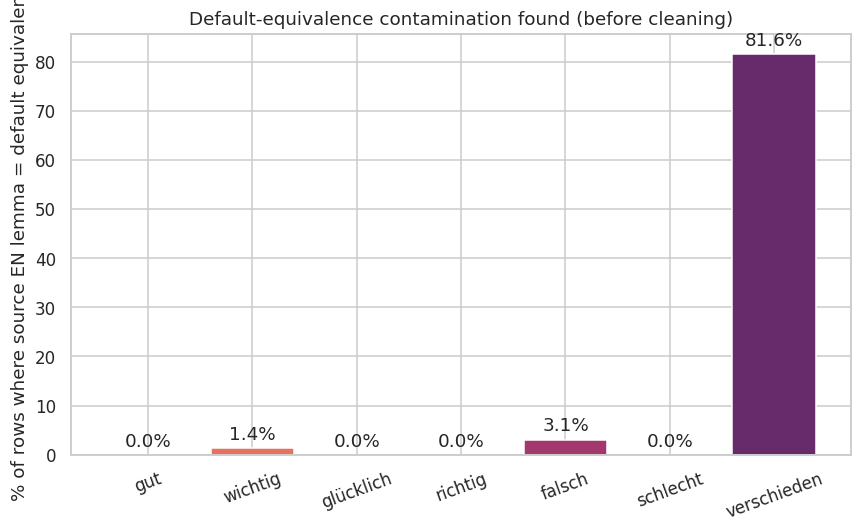

In [5]:

sanity_rows = []
for adj in TARGET_ADJECTIVES:
    sub = df[df["target_adjective"] == adj]
    default_eq = DEFAULT_EQUIVALENT[adj]
    n_default = (sub["token_lemma"].str.lower() == default_eq).sum()
    sanity_rows.append({
        "target_adjective": adj,
        "expected_default_EN_equivalent": default_eq,
        "n_rows_with_default_equivalent": n_default,
        "n_total_rows_before_cleaning": len(sub),
        "pct_default_equivalent": round(100 * n_default / len(sub), 1) if len(sub) else np.nan,
    })
sanity = pd.DataFrame(sanity_rows).set_index("target_adjective")
display(sanity)
sanity.to_csv(os.path.join(OUTPUT_DIR, "task2_equivalence_contamination_check.csv"))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sanity.index, sanity["pct_default_equivalent"],
              color=sns.color_palette("flare", len(sanity)))
ax.set_ylabel("% of rows where source EN lemma = default equivalent")
ax.set_title("Default-equivalence contamination found (before cleaning)")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task2_equivalence_contamination_before.png"))
plt.show()


In [6]:

# Remove rows where the source lemma equals the default equivalent of the target adjective
def _is_default_equivalent(row):
    return row["token_lemma"].lower() == DEFAULT_EQUIVALENT[row["target_adjective"]]

contamination_mask = df.apply(_is_default_equivalent, axis=1)
print(f"Removing {contamination_mask.sum()} contaminating rows out of {len(df)} total")

df = df[~contamination_mask].reset_index(drop=True)

print(f"Cleaned dataset: {len(df)} rows\n")
print("Rows remaining per adjective:")
print(df["target_adjective"].value_counts().reindex(TARGET_ADJECTIVES))


Removing 153 contaminating rows out of 489 total
Cleaned dataset: 336 rows

Rows remaining per adjective:
target_adjective
gut            112
wichtig         68
glücklich        3
richtig         44
falsch          31
schlecht        44
verschieden     34
Name: count, dtype: int64



## 3. Dataset overview

How many annotated tokens does each of the 7 target adjectives contribute? This matters
because the adjectives are very unevenly represented in this dataset (e.g. *verschieden*
has far more tokens than *glücklich*), which we need to keep in mind when comparing rates
across adjectives later — small-n adjectives (like *glücklich*, n=3) will be noisy.


,n_tokens
target_adjective,
glücklich,3
falsch,31
verschieden,34
richtig,44
schlecht,44
wichtig,68
gut,112


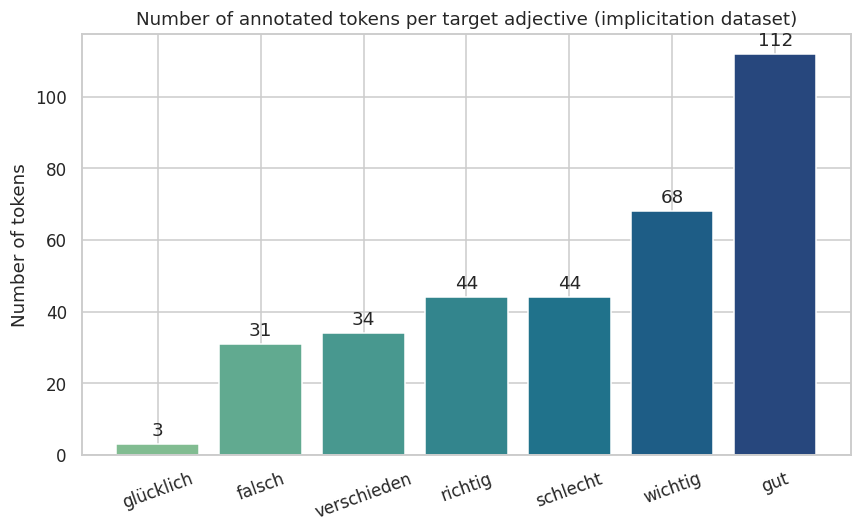

In [7]:
counts = (
    df["target_adjective"]
    .value_counts()
    .reindex(TARGET_ADJECTIVES)
    .sort_values(ascending=True)
)

display(counts.to_frame("n_tokens"))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    counts.index,
    counts.values,
    color=sns.color_palette("crest", len(counts))
)

ax.set_title("Number of annotated tokens per target adjective (implicitation dataset)")
ax.set_ylabel("Number of tokens")
ax.bar_label(bars, padding=3)

plt.xticks(rotation=20)
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, "task2_tokens_per_adjective.png"))
plt.show()


## 4. Domain and speaker-gender distribution

The talks these sentences come from are tagged by subject domain (e.g. Art, Business,
Education, Technology...) and by the gender of the speaker. A quick look at these
distributions tells us whether the implicitation dataset is skewed toward particular
domains/speakers, which is useful context for interpreting the domain- and gender-level
results in Tasks 10–11.


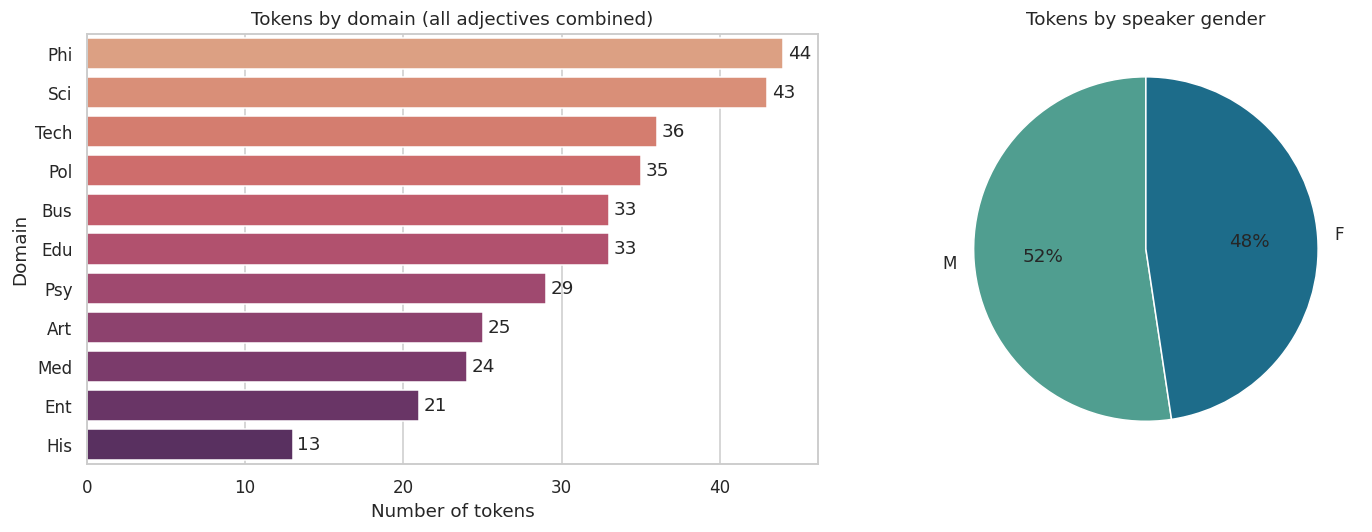

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Domain counts
domain_counts = df["Domain"].value_counts()

bars = sns.barplot(
    x=domain_counts.values,
    y=domain_counts.index,
    ax=axes[0],
    hue=domain_counts.index,
    palette="flare",
    legend=False
)

axes[0].set_title("Tokens by domain (all adjectives combined)")
axes[0].set_xlabel("Number of tokens")
axes[0].set_ylabel("Domain")

# Add count labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", padding=3)

# Gender pie chart
gender_counts = df["Gender"].value_counts()

axes[1].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.0f%%",
    colors=sns.color_palette("crest", len(gender_counts)),
    startangle=90
)
axes[1].set_title("Tokens by speaker gender")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task3_domain_gender.png"))
plt.show()


## 5. Which English adjectives get "levelled" into each German core adjective?

This is the heart of what makes this dataset special: for each target German adjective, what
range of English source adjectives (`token_lemma`) get translated into it? A wide, varied set
of source lemmas (e.g. *great, fine, nice, dear, smart...* all becoming *gut*) is itself
evidence of a "levelling"/implicitation pattern — many distinct, more specific English
meanings collapsing onto one general-purpose German adjective.

For each adjective we report (a) how many distinct English lemmas feed into it, and
(b) the most frequent ones.

The default-equivalence contamination flagged and removed in Task 2 (e.g. *different* for *verschieden*) has already been removed, so it will not appear in the lemma lists below.


In [9]:

diversity_rows = []
for adj in TARGET_ADJECTIVES:
    sub = df[df["target_adjective"] == adj]
    n_types = sub["token_lemma"].nunique()
    n_tokens = len(sub)
    diversity_rows.append({
        "target_adjective": adj,
        "n_tokens": n_tokens,
        "n_distinct_EN_lemmas": n_types,
        "type_token_ratio": round(n_types / n_tokens, 2) if n_tokens else np.nan,
    })
diversity = pd.DataFrame(diversity_rows).set_index("target_adjective").reindex(TARGET_ADJECTIVES)
display(diversity)
diversity.to_csv(os.path.join(OUTPUT_DIR, "task4_source_lemma_diversity.csv"))


,n_tokens,n_distinct_EN_lemmas,type_token_ratio
target_adjective,,,
gut,112,57,0.51
wichtig,68,34,0.50
glücklich,3,3,1.00
richtig,44,25,0.57
falsch,31,14,0.45
schlecht,44,24,0.55
verschieden,34,13,0.38


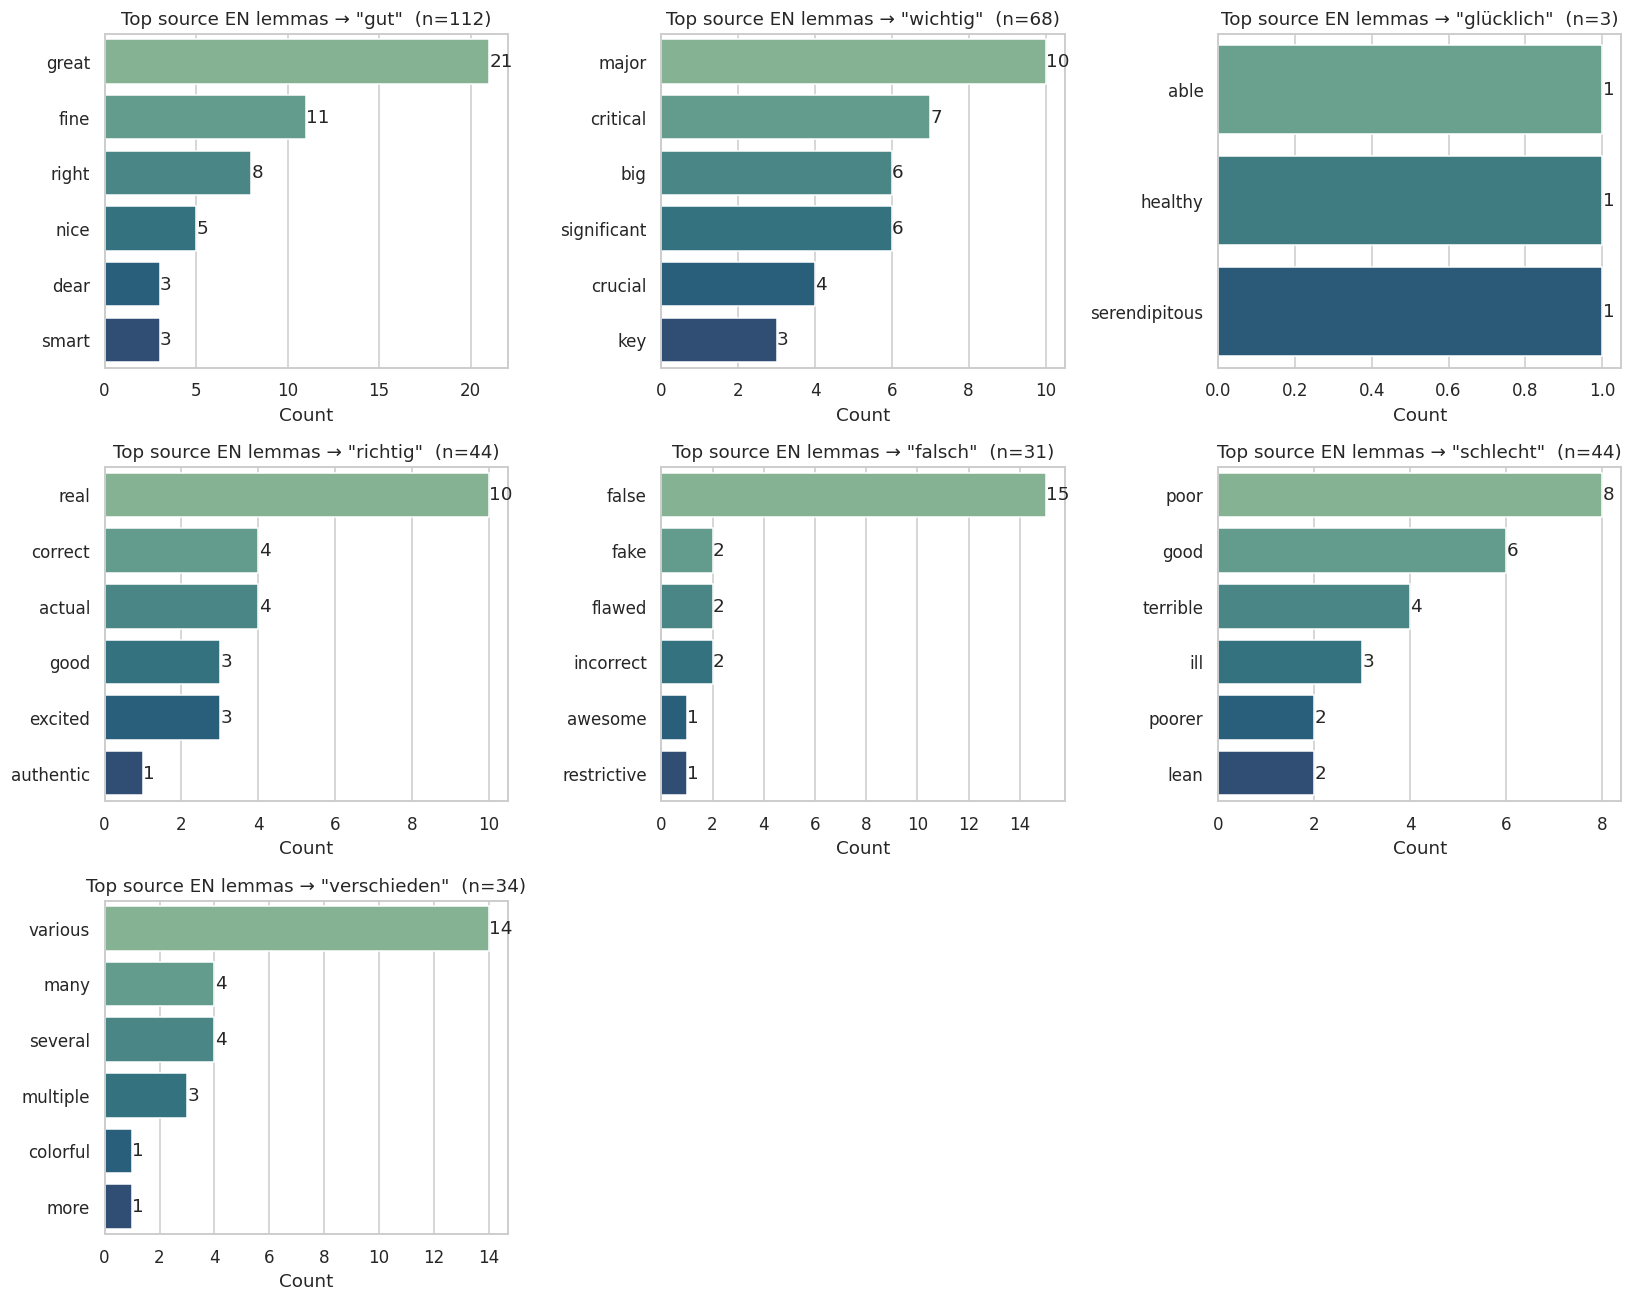

In [10]:
# Small multiples: top 6 source EN lemmas feeding into each target adjective
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, adj in enumerate(TARGET_ADJECTIVES):
    sub = df[df["target_adjective"] == adj]
    top = sub["token_lemma"].value_counts().head(6)

    sns.barplot(
        x=top.values,
        y=top.index,
        ax=axes[i],
        hue=top.index,
        palette="crest",
        legend=False
    )

    axes[i].set_title(f'Top source EN lemmas → "{adj}"  (n={len(sub)})')
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

    # Add count labels
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%d", padding=0.25)

for j in range(len(TARGET_ADJECTIVES), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task4_top_source_lemmas.png"))
plt.show()


## 6. Translation strategy: Equivalence vs. Alteration

`Translation_strategy` codes whether the *evaluative meaning* of the sentence was preserved
across the translation (**Equivalence**) or changed (**Alteration**) — independent of whether
the exact same lemma was used. Rows with a missing value are cases the annotator left
uncoded (a small residual category — reported separately below rather than silently dropped).
This tells us, per target adjective, how often translators' word choice actually changed the
evaluative meaning versus keeping it equivalent.


Translation_strategy_,Alteration,Equivalence,Not coded
target_adjective,,,
gut,28,65,19
wichtig,19,49,0
glücklich,0,2,1
richtig,3,38,3
falsch,3,25,3
schlecht,13,24,7
verschieden,13,20,1


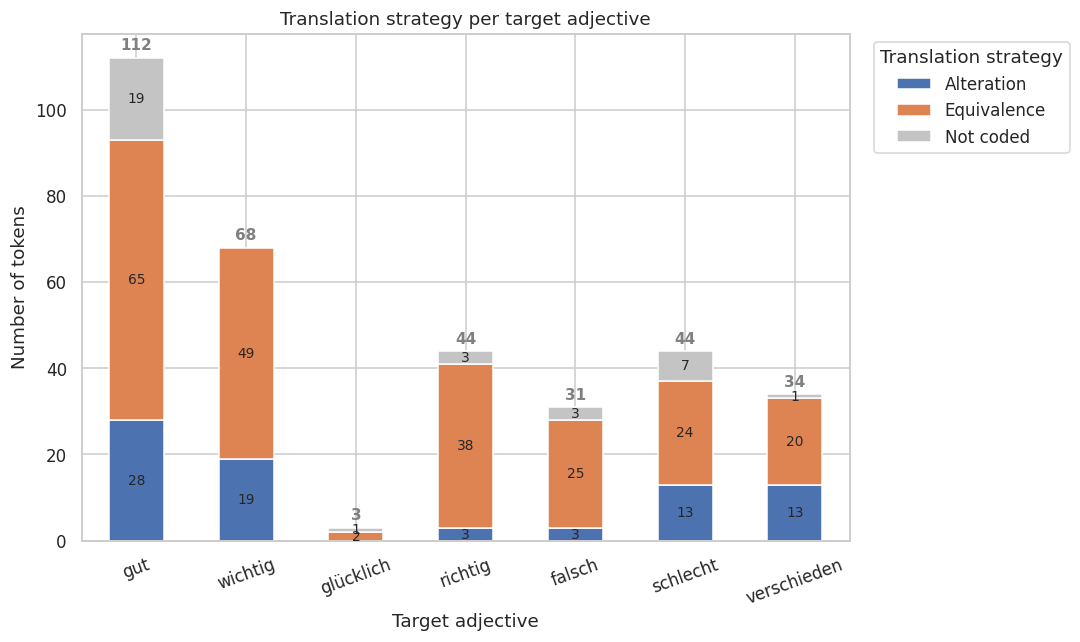

In [11]:
strat = df.copy()
strat["Translation_strategy_"] = strat["Translation_strategy"].fillna("Not coded")

strat_ct = pd.crosstab(strat["target_adjective"], strat["Translation_strategy_"])
strat_ct = strat_ct.reindex(TARGET_ADJECTIVES)

display(strat_ct)
strat_ct.to_csv(os.path.join(OUTPUT_DIR, "task6_translation_strategy_counts.csv"))


fig, ax = plt.subplots(figsize=(10, 6))

# Plot actual counts (not proportions)
strat_ct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#4C72B0", "#DD8452", "#C4C4C4"]
)

ax.set_ylabel("Number of tokens")
ax.set_xlabel("Target adjective")
ax.set_title("Translation strategy per target adjective")

# Add counts inside each segment
for container in ax.containers:
    labels = [int(v.get_height()) if v.get_height() > 0 else "" for v in container]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

# Add total count above each bar
totals = strat_ct.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + max(totals)*0.01,
        f"{total}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color ="gray"
    )

ax.legend(
    title="Translation strategy",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "task6_translation_strategy.png")
)

plt.show()


## 7. Translationese effect — Implicitation vs. Explicitation (the key variable)

This is the central variable for the implicitation study: whenever `Translation_strategy`
is *Alteration*, `Translationese_effect` records whether that alteration made the evaluative
meaning **more implicit** (Implicitation — a more general/basic word standing in for a more
specific one) or **more explicit** (Explicitation). Rows with no effect coded are cases with
no alteration (mostly Equivalence rows) and are labelled "None" below rather than dropped, so
that percentages are computed over the full dataset per adjective.


In [12]:

eff = df.copy()
eff["Translationese_effect_"] = eff["Translationese_effect"].fillna("None")

eff_ct = pd.crosstab(eff["target_adjective"], eff["Translationese_effect_"])
eff_ct = eff_ct.reindex(TARGET_ADJECTIVES)[["Implicitation", "Explicitation", "None"]]
display(eff_ct)
eff_ct.to_csv(os.path.join(OUTPUT_DIR, "task7_translationese_effect_counts.csv"))

eff_prop = eff_ct.div(eff_ct.sum(axis=1), axis=0)
eff_prop.to_csv(os.path.join(OUTPUT_DIR, "task7_translationese_effect_proportions.csv"))
display(eff_prop.round(3))


Translationese_effect_,Implicitation,Explicitation,None
target_adjective,,,
gut,25,4,83
wichtig,17,2,49
glücklich,0,0,3
richtig,2,1,41
falsch,1,2,28
schlecht,12,1,31
verschieden,11,2,21


Translationese_effect_,Implicitation,Explicitation,None
target_adjective,,,
gut,0.223,0.036,0.741
wichtig,0.250,0.029,0.721
glücklich,0.000,0.000,1.000
richtig,0.045,0.023,0.932
falsch,0.032,0.065,0.903
schlecht,0.273,0.023,0.705
verschieden,0.324,0.059,0.618


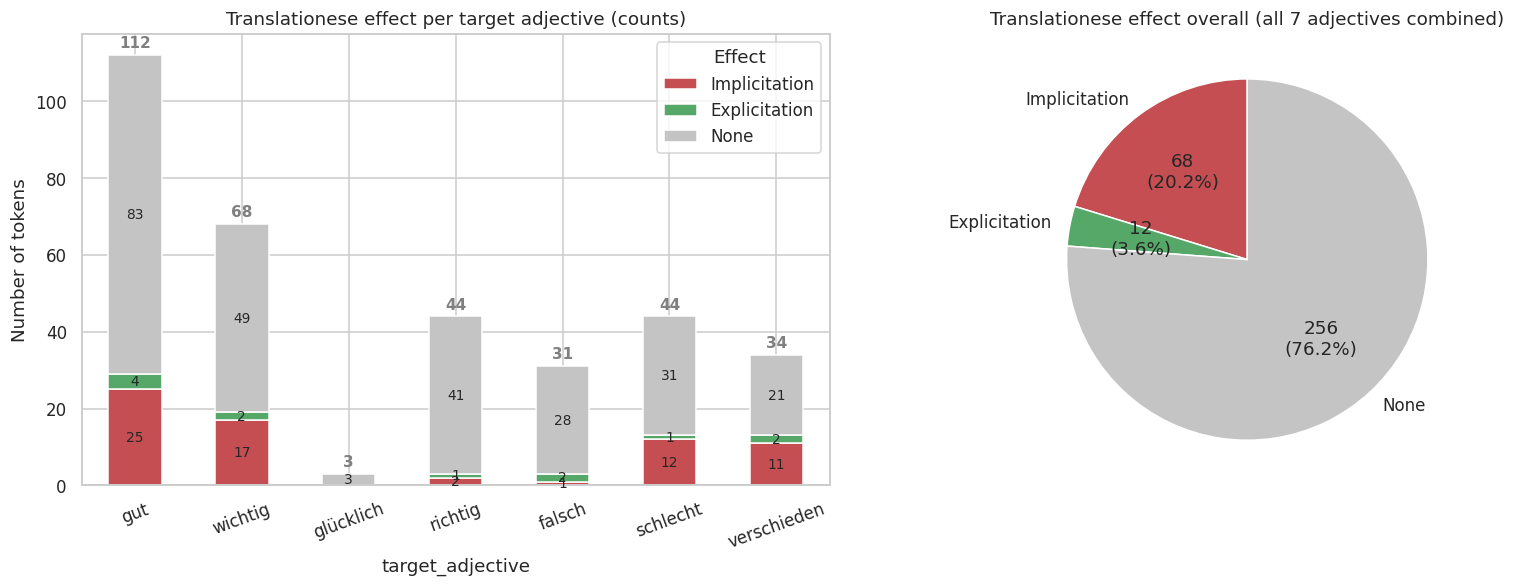

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ---- Stacked bar chart with counts ----
eff_ct.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=["#C44E52", "#55A868", "#C4C4C4"]
)

axes[0].set_ylabel("Number of tokens")
axes[0].set_title("Translationese effect per target adjective (counts)")
axes[0].legend(title="Effect", loc="upper right")
axes[0].tick_params(axis="x", rotation=20)

# Add counts inside segments
for container in axes[0].containers:
    labels = [
        str(int(v.get_height())) if v.get_height() > 0 else ""
        for v in container
    ]
    axes[0].bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

# Add total count above bars
totals = eff_ct.sum(axis=1)

for i, total in enumerate(totals):
    axes[0].text(
        i,
        total + max(totals) * 0.01,
        f"{total}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="gray"
    )


# ---- Pie chart with counts + percentages ----
overall = eff_ct.sum(axis=0)

def autopct_with_counts(values):
    def formatter(pct):
        count = int(round(pct * sum(values) / 100))
        return f"{count}\n({pct:.1f}%)"
    return formatter

axes[1].pie(
    overall.values,
    labels=overall.index,
    autopct=autopct_with_counts(overall.values),
    colors=["#C44E52", "#55A868", "#C4C4C4"],
    startangle=90
)

axes[1].set_title("Translationese effect overall (all 7 adjectives combined)")


plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "task7_translationese_effect.png")
)

plt.show()

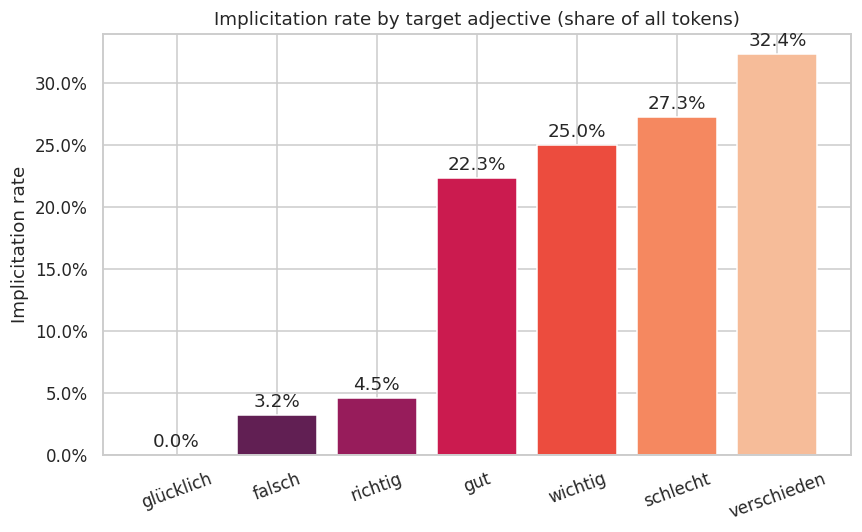

In [ ]:
# Implicitation rate specifically (Implicitation / total tokens), per adjective, sorted ascending
implicitation_rate = (
    eff_ct["Implicitation"] / eff_ct.sum(axis=1)
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    implicitation_rate.index,
    implicitation_rate.values,
    color=sns.color_palette("rocket", len(implicitation_rate))
)

ax.set_ylabel("Implicitation rate")
ax.set_title("Implicitation rate by target adjective (share of all tokens)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

ax.bar_label(
    bars,
    labels=[f"{v*100:.1f}%" for v in implicitation_rate.values],
    padding=3
)

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "task7_implicitation_rate_ranked.png")
)

plt.show()


## 8. How translation strategy and translationese effect relate

As a consistency check on the coding scheme itself: `Translationese_effect` should only be
coded when `Translation_strategy` is *Alteration*. The heatmap below confirms this (or shows
any exceptions) across the full dataset.


Translationese_effect_,Explicitation,Implicitation,None
Translation_strategy_,,,
Alteration,11,68,0
Equivalence,1,0,222
Not coded,0,0,34


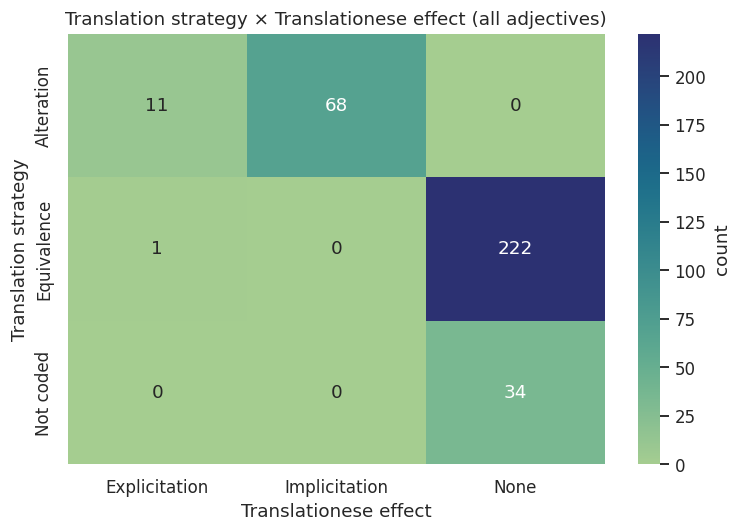

In [ ]:

cross = pd.crosstab(strat["Translation_strategy_"], eff["Translationese_effect_"])
display(cross)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cross, annot=True, fmt="d", cmap="crest", ax=ax, cbar_kws={"label": "count"})
ax.set_title("Translation strategy × Translationese effect (all adjectives)")
ax.set_xlabel("Translationese effect")
ax.set_ylabel("Translation strategy")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task8_strategy_vs_effect_heatmap.png"))
plt.show()



## 9. Does evaluative meaning survive the translation? (EN vs. DE evaluativity)

`EN_Evaluative?` / `DE_Evaluative?` code whether the adjective's use in that sentence is
evaluative (expresses a stance) or non-evaluative, in English and German respectively. Here
we check how often that evaluativity status changes between the two languages, and then
specifically how that lines up with rows coded as Implicitation — implicitation is often
expected to *reduce* the explicitness of evaluation, so it's worth seeing whether it also
sometimes flips a sentence from evaluative to non-evaluative altogether.


DE_Evaluative?,Evaluative,Evaluative-not_speaker,Non-evaluative
EN_Evaluative?,,,
Evaluative,254,1,5
Evaluative-not_speaker,0,35,0
Non-evaluative,7,1,32
Uncertain,1,0,0


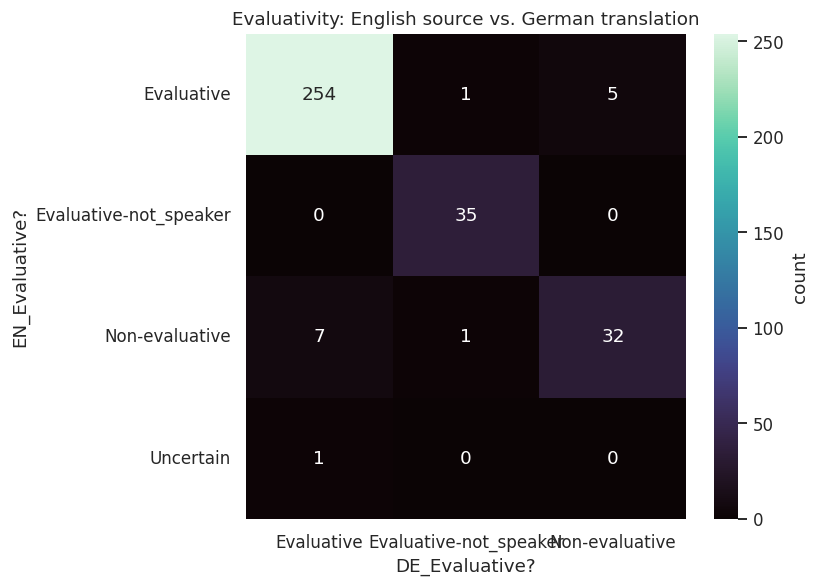

In [ ]:

ev = df.copy()
ev["EN_Evaluative?"] = ev["EN_Evaluative?"].fillna("Not coded")
ev["DE_Evaluative?"] = ev["DE_Evaluative?"].fillna("Not coded")

ev_cross = pd.crosstab(ev["EN_Evaluative?"], ev["DE_Evaluative?"])
display(ev_cross)
ev_cross.to_csv(os.path.join(OUTPUT_DIR, "task9_evaluativity_shift.csv"))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(ev_cross, annot=True, fmt="d", cmap="mako", ax=ax, cbar_kws={"label": "count"})
ax.set_title("Evaluativity: English source vs. German translation")
ax.set_xlabel("DE_Evaluative?")
ax.set_ylabel("EN_Evaluative?")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task9_evaluativity_heatmap.png"))
plt.show()


Implicitation rows: 68
evaluativity_changed
False    63
True      5
Name: count, dtype: int64


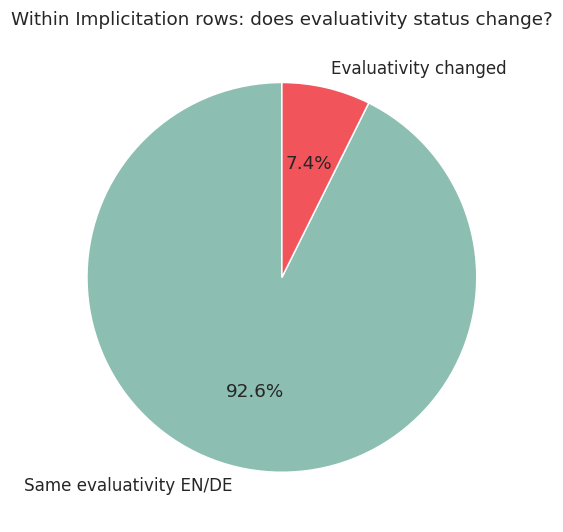

In [ ]:

# Among Implicitation rows only: does evaluativity status change?
impl_rows = df[df["Translationese_effect"] == "Implicitation"].copy()
impl_rows["EN_Evaluative?"] = impl_rows["EN_Evaluative?"].fillna("Not coded")
impl_rows["DE_Evaluative?"] = impl_rows["DE_Evaluative?"].fillna("Not coded")
impl_rows["evaluativity_changed"] = impl_rows["EN_Evaluative?"] != impl_rows["DE_Evaluative?"]

print(f"Implicitation rows: {len(impl_rows)}")
print(impl_rows["evaluativity_changed"].value_counts())

fig, ax = plt.subplots(figsize=(5.5, 5))
vc = impl_rows["evaluativity_changed"].value_counts()
ax.pie(vc.values, labels=["Same evaluativity EN/DE" if not v else "Evaluativity changed" for v in vc.index],
       autopct="%1.1f%%", colors=["#8CBEB2", "#F2545B"], startangle=90)
ax.set_title("Within Implicitation rows: does evaluativity status change?")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task9_implicitation_evaluativity_change.png"))
plt.show()



## 10. Attitude type: Appreciation, Judgement, Affect — EN vs. DE, and vs. implicitation

`EN_Attitude_type` / `DE_Attitude_type` classify *what kind* of evaluation is being made
(Appreciation = evaluating things/phenomena, Judgement = evaluating people's behaviour,
Affect = expressing emotion), following the Appraisal framework. First we check how stable
these categories are across languages; then we look specifically at which attitude types
are most associated with implicitation — e.g. is implicitation more common when the original
was an Appreciation than a Judgement?


DE_Attitude_type,Affect,Appreciation,Judgement,Not coded/Non-evaluative
EN_Attitude_type,,,,
Affect,12,1,1,0
Appreciation,0,234,1,4
Judgement,0,0,41,1
Not coded/Non-evaluative,0,5,3,33


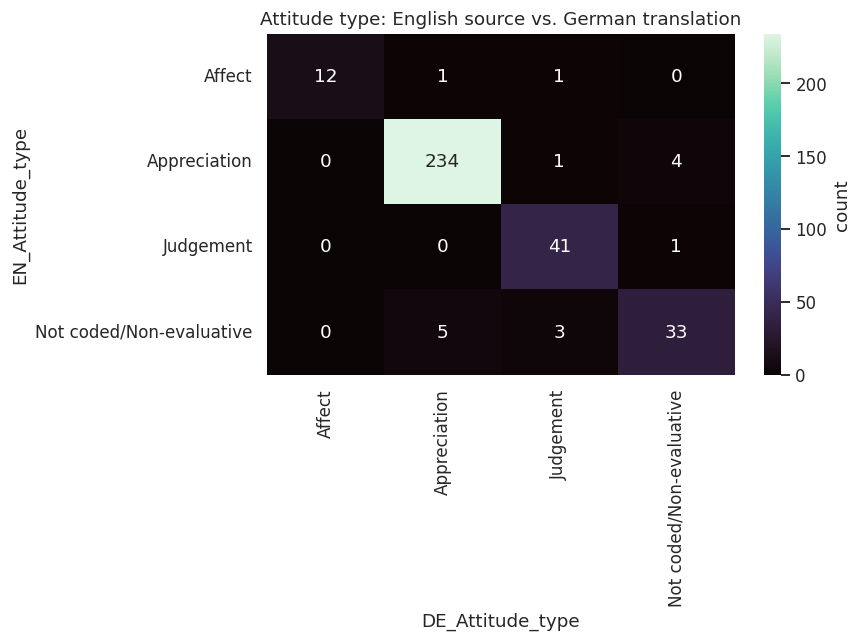

In [ ]:

at = df.copy()
at["EN_Attitude_type"] = at["EN_Attitude_type"].fillna("Not coded/Non-evaluative")
at["DE_Attitude_type"] = at["DE_Attitude_type"].fillna("Not coded/Non-evaluative")

at_cross = pd.crosstab(at["EN_Attitude_type"], at["DE_Attitude_type"])
display(at_cross)
at_cross.to_csv(os.path.join(OUTPUT_DIR, "task10_attitude_type_shift.csv"))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(at_cross, annot=True, fmt="d", cmap="mako", ax=ax, cbar_kws={"label": "count"})
ax.set_title("Attitude type: English source vs. German translation")
ax.set_xlabel("DE_Attitude_type")
ax.set_ylabel("EN_Attitude_type")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task10_attitude_type_heatmap.png"))
plt.show()


,n_implicitation_rows
EN_Attitude_type,
Appreciation,55
Judgement,11
Affect,2


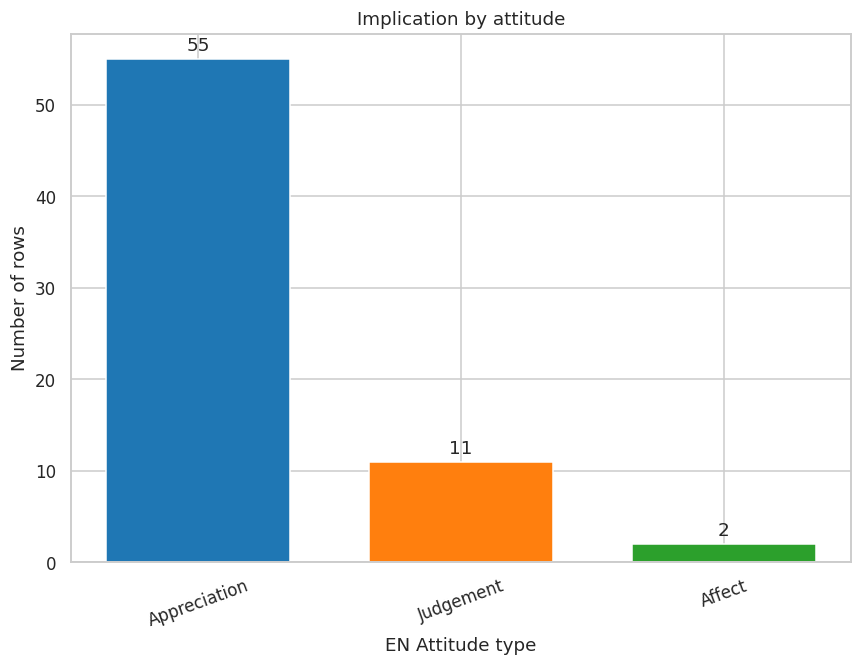

In [15]:
# Attitude type (source, EN) breakdown specifically among Implicitation rows
impl_attitude = (
    df[df["Translationese_effect"] == "Implicitation"]["EN_Attitude_type"]
    .fillna("Not coded")
    .value_counts()
)

display(impl_attitude.to_frame("n_implicitation_rows"))

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    impl_attitude.index,
    impl_attitude.values,
    color=["tab:blue", "tab:orange", "tab:green"][:len(impl_attitude)],
    width=0.7
)

ax.set_ylabel("Number of rows")
ax.set_xlabel("EN Attitude type")

ax.bar_label(bars, padding=3)

plt.xticks(rotation=20)
plt.tight_layout()
plt.title("Implication by attitude")
plt.savefig(
    os.path.join(OUTPUT_DIR, "task10_implicitation_by_attitude_type.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 11. Implicitation rate by domain

Does implicitation happen more in some subject domains (e.g. Business, Technology) than
others (e.g. Art, Education)? We compute the implicitation rate per domain across all 7
adjectives combined. Domains with very few tokens overall are noisy, so the underlying
counts are shown alongside the rate.


,n_tokens,n_implicitation,implicitation_rate
Domain,,,
His,13,4,0.307692
Med,24,7,0.291667
Pol,35,10,0.285714
Edu,33,9,0.272727
Ent,21,5,0.238095
Tech,36,8,0.222222
Bus,33,7,0.212121
Phi,44,9,0.204545
Psy,29,4,0.137931


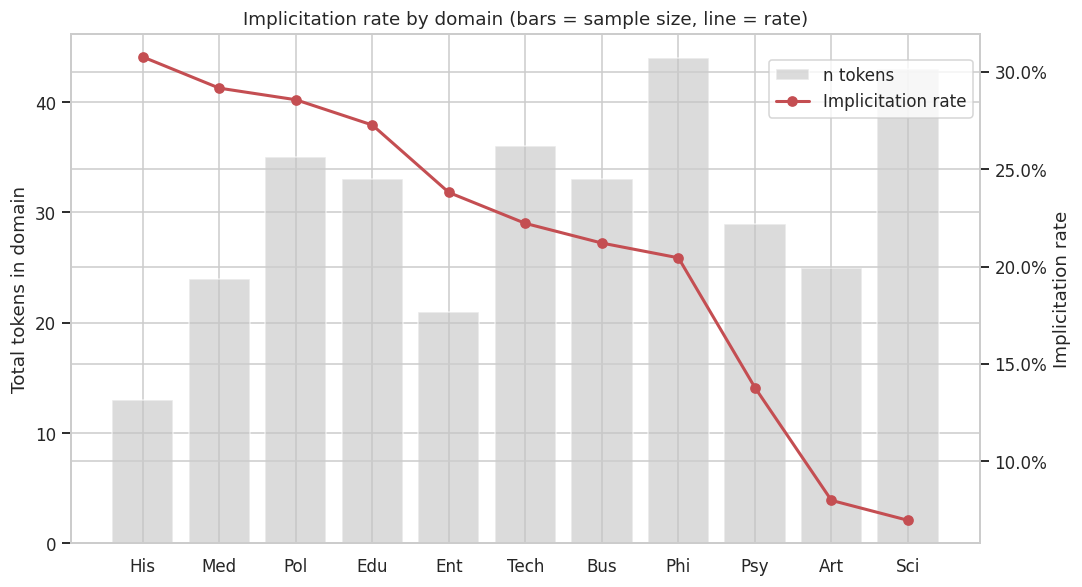

In [ ]:

dom = df.copy()
dom["is_implicitation"] = dom["Translationese_effect"] == "Implicitation"

dom_summary = dom.groupby("Domain").agg(
    n_tokens=("is_implicitation", "size"),
    n_implicitation=("is_implicitation", "sum"),
)
dom_summary["implicitation_rate"] = dom_summary["n_implicitation"] / dom_summary["n_tokens"]
dom_summary = dom_summary.sort_values("implicitation_rate", ascending=False)
display(dom_summary)
dom_summary.to_csv(os.path.join(OUTPUT_DIR, "task11_domain_implicitation_rate.csv"))

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax2 = ax1.twinx()

ax1.bar(dom_summary.index, dom_summary["n_tokens"], color="#C4C4C4", alpha=0.6, label="n tokens")
ax1.set_ylabel("Total tokens in domain")

ax2.plot(dom_summary.index, dom_summary["implicitation_rate"], color="#C44E52",
         marker="o", linewidth=2, label="Implicitation rate")
ax2.set_ylabel("Implicitation rate")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

ax1.set_title("Implicitation rate by domain (bars = sample size, line = rate)")
plt.xticks(rotation=30, ha="right")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task11_domain_implicitation_rate.png"))
plt.show()



## 12. Implicitation rate by speaker gender

The same question, broken down by the gender of the original English speaker: does the
implicitation rate differ between talks given by men vs. women?


,n_tokens,n_implicitation,implicitation_rate
Gender,,,
F,160,35,0.21875
M,176,33,0.18750


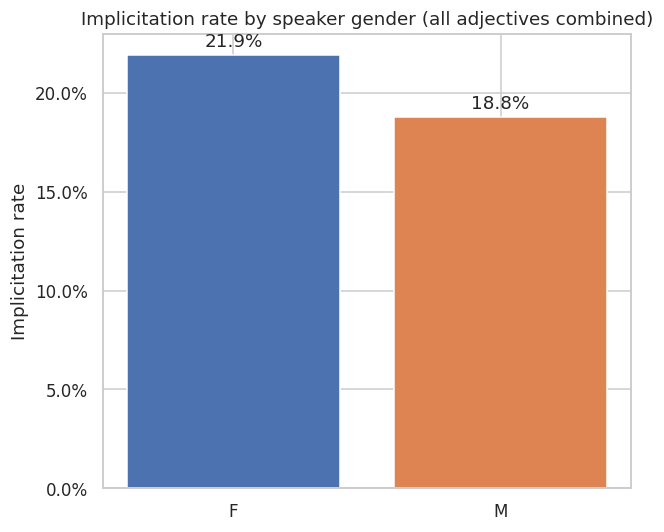

In [14]:

gen = df.copy()
gen["is_implicitation"] = gen["Translationese_effect"] == "Implicitation"

gen_summary = gen.groupby("Gender").agg(
    n_tokens=("is_implicitation", "size"),
    n_implicitation=("is_implicitation", "sum"),
)
gen_summary["implicitation_rate"] = gen_summary["n_implicitation"] / gen_summary["n_tokens"]
display(gen_summary)
gen_summary.to_csv(os.path.join(OUTPUT_DIR, "task12_gender_implicitation_rate.csv"))

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(gen_summary.index, gen_summary["implicitation_rate"],
              color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Implicitation rate")
ax.set_title("Implicitation rate by speaker gender (all adjectives combined)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.bar_label(bars, fmt="%.1f%%", labels=[f"{v*100:.1f}%" for v in gen_summary["implicitation_rate"]], padding=3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task12_gender_implicitation_rate.png"))
plt.show()



## 13. Export the combined dataset and summary tables

Save the full combined dataset (all 7 adjectives, one row per token) as a single CSV, plus
a compact per-adjective summary table pulling together the key numbers from Tasks 2, 6 and 7.
All files (this one plus every chart/table saved earlier) are written to
`/mnt/user-data/outputs/` for direct use in the write-up.


In [ ]:

df.to_csv(os.path.join(OUTPUT_DIR, "implicitation_dataset_combined.csv"), index=False)

# strat_prop (used below) isn't computed elsewhere in this version of the notebook,
# since the Task 6 chart was switched to plot counts instead of proportions.
strat_prop = strat_ct.div(strat_ct.sum(axis=1), axis=0)

summary = pd.DataFrame({
    "n_tokens": counts,
    "n_distinct_EN_lemmas": diversity["n_distinct_EN_lemmas"],
    "pct_default_equivalent_contamination": sanity["pct_default_equivalent"],
    "pct_alteration": strat_prop.get("Alteration", pd.Series(0, index=TARGET_ADJECTIVES)) * 100,
    "pct_implicitation": eff_prop["Implicitation"] * 100,
    "pct_explicitation": eff_prop["Explicitation"] * 100,
}).round(1)

display(summary)
summary.to_csv(os.path.join(OUTPUT_DIR, "task13_master_summary_table.csv"))
print("\nAll outputs written to:", OUTPUT_DIR)


,n_tokens,n_distinct_EN_lemmas,pct_default_equivalent_contamination,pct_alteration,pct_implicitation,pct_explicitation
target_adjective,,,,,,
falsch,31,14,3.1,9.7,3.2,6.5
glücklich,3,3,0.0,0.0,0.0,0.0
gut,112,57,0.0,25.0,22.3,3.6
richtig,44,25,0.0,6.8,4.5,2.3
schlecht,44,24,0.0,29.5,27.3,2.3
verschieden,34,13,81.6,38.2,32.4,5.9
wichtig,68,34,1.4,27.9,25.0,2.9



All outputs written to: /mnt/user-data/outputs



## 14. The "normal" dataset: the 17 English adjectives

So far, everything above came from the **special implicitation dataset**: 7 files, one per
German target adjective, deliberately curated to contain *non-default* English source
adjectives (e.g. *great → gut*, not *good → gut*).

We now bring in a second, differently-organised dataset: **17 files, one per English source
adjective** (`good`, `important`, `happy`, `right`, `wrong`, `bad`, `different`, plus 10
further evaluative adjectives: `amazing`, `beautiful`, `creative`, `difficult`,
`extraordinary`, `fantastic`, `fascinating`, `incredible`, `interesting`, `wonderful`). Unlike
the special dataset, this one is **not** filtered to exclude default equivalence pairs — for
a given English word, it contains *every* German translation it received, including the
expected default equivalent as well as any alterations.

Seven of these 17 English adjectives — `good`, `important`, `happy`, `right`, `wrong`, `bad`,
`different` — are exactly the direct English equivalents of the 7 German core adjectives
already analysed (gut, wichtig, glücklich, richtig, falsch, schlecht, verschieden). These
7 give us the **normal/baseline translation behaviour** of the core adjectives themselves,
which is exactly what we need to compare against the implicitation-dataset rates from Task 7.

The remaining 10 adjectives (amazing, wonderful, fantastic...) are stronger/more specific
evaluative adjectives not part of the core 7 — we profile them briefly for context, but the
main comparison below uses only the 7 core ones.


In [ ]:
!unzip English\ adjectives.zip

Archive:  English adjectives.zip
replace English adjectives/amazing_Bianca.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace English adjectives/bad_Bianca.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace English adjectives/beautiful_Bianca.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace English adjectives/creative_Bianca.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace English adjectives/different_Bianca.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace English adjectives/difficult_Bianca.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace English adjectives/extraordinary Bianca.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace English adjectives/fantastic Bianca.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace English adjectives/fascinating Bianca.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace English adjectives/good_Bianca.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace English adjectives/happy_Bianca.xlsx? [y]es, [n]o, [A]ll, [N]one, [

In [ ]:

import glob

NORMAL_DATA_DIR = "English adjectives"

normal_paths = glob.glob(os.path.join(NORMAL_DATA_DIR, "*.xlsx"))
print(f"Found {len(normal_paths)} files")

normal_frames = []
for p in normal_paths:
    base = os.path.basename(p)
    # filenames are inconsistent: some use "_Bianca.xlsx", others " Bianca.xlsx"
    adj = base.replace("_Bianca.xlsx", "").replace(" Bianca.xlsx", "")
    d = pd.read_excel(p)
    d["source_adjective"] = adj
    normal_frames.append(d)

normal_df = pd.concat(normal_frames, ignore_index=True, sort=False)
print(f"Combined 'normal' dataset: {normal_df.shape[0]} rows, {normal_df.shape[1]} columns")
normal_df["source_adjective"].value_counts()


Found 17 files
Combined 'normal' dataset: 3078 rows, 19 columns


,count
source_adjective,
good,848
different,394
right,393
bad,251
important,248
wrong,172
interesting,129
amazing,123
happy,121



## 15. Cleaning: lemma-matching noise in the source files

Because these files were built by searching for each English word in the corpus, a handful
of unrelated words with overlapping substrings slipped in — e.g. `bright` and `upright`
inside the `right` file, and `indifferent`/`differential` inside the `different` file. These
are not forms of "right" or "different" and would distort the core-adjective comparison, so
we drop any row where `token_lemma` doesn't exactly match the file's intended source
adjective.


In [ ]:

mismatch = normal_df[normal_df["token_lemma"].str.lower() != normal_df["source_adjective"].str.lower()]
print(f"Rows with a mismatched lemma (noise): {len(mismatch)} of {len(normal_df)}")
display(mismatch.groupby(["source_adjective", "token_lemma"]).size().to_frame("n_rows"))

normal_df_clean = normal_df[
    normal_df["token_lemma"].str.lower() == normal_df["source_adjective"].str.lower()
].copy()
print(f"\nAfter cleaning: {len(normal_df_clean)} rows (removed {len(normal_df) - len(normal_df_clean)})")


Rows with a mismatched lemma (noise): 33 of 3078


n_rows
source_adjective token_lemma         
different        differential       2
                 indifferent        3
right            bright            22
                 brightest          1
                 forthright         1
                 frightening        1
                 outright           1
                 righteous          1
                 upright            1


After cleaning: 3045 rows (removed 33)



## 16. Subsetting to the 7 core adjectives

We keep only the 7 English adjectives that are direct equivalents of our German core
adjectives, and map each to its German counterpart so it lines up with `target_adjective`
from the implicitation dataset (Tasks 1–13).


,n_tokens_normal_dataset
target_adjective,
glücklich,121
falsch,172
wichtig,248
schlecht,251
richtig,365
verschieden,389
gut,848


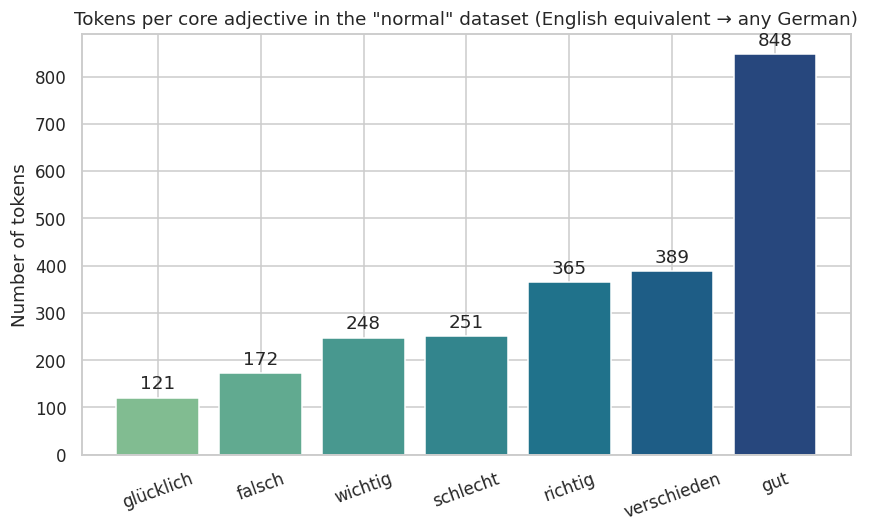

In [ ]:
CORE_EQUIVALENT_MAP = {
    "good": "gut",
    "important": "wichtig",
    "happy": "glücklich",
    "right": "richtig",
    "wrong": "falsch",
    "bad": "schlecht",
    "different": "verschieden",
}

normal_core = normal_df_clean[
    normal_df_clean["source_adjective"].isin(CORE_EQUIVALENT_MAP)
].copy()

normal_core["target_adjective"] = normal_core["source_adjective"].map(CORE_EQUIVALENT_MAP)

normal_core_counts = (
    normal_core["target_adjective"]
    .value_counts()
    .reindex(TARGET_ADJECTIVES)
    .sort_values(ascending=True)
)

display(normal_core_counts.to_frame("n_tokens_normal_dataset"))

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    normal_core_counts.index,
    normal_core_counts.values,
    color=sns.color_palette("crest", len(normal_core_counts))
)

ax.set_title('Tokens per core adjective in the "normal" dataset (English equivalent → any German)')
ax.set_ylabel("Number of tokens")

ax.bar_label(bars, padding=3)

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "task16_normal_tokens_per_adjective.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 17. Translation strategy and translationese effect in the normal dataset

Exactly as in Tasks 6–7, but now for the normal, non-curated occurrences of the 7 core
adjectives. Because most tokens here *are* the default equivalence pair (e.g. good → gut),
we expect Alteration/Implicitation to be considerably rarer than in the special
implicitation dataset — that difference is precisely what we quantify in Task 18.


Translation_strategy_,Alteration,Equivalence,Not coded
target_adjective,,,
gut,73,659,116
wichtig,19,229,0
glücklich,4,110,7
richtig,32,261,72
falsch,7,155,10
schlecht,22,221,8
verschieden,38,348,3


Translationese_effect_,Implicitation,Explicitation,None
target_adjective,,,
gut,25,50,773
wichtig,15,4,229
glücklich,4,0,117
richtig,28,4,333
falsch,5,2,165
schlecht,12,10,229
verschieden,26,12,351


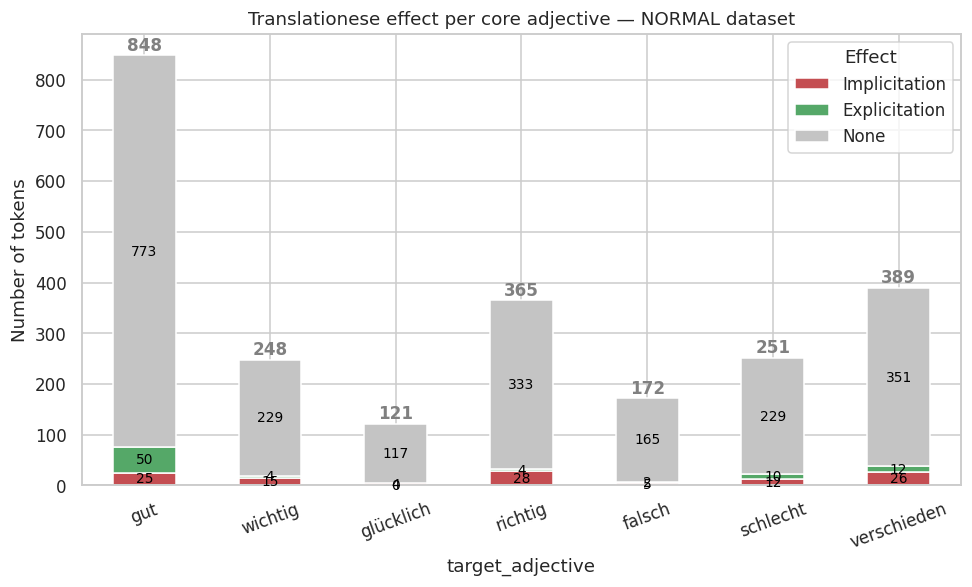

In [ ]:

normal_strat = normal_core.copy()
normal_strat["Translation_strategy_"] = normal_strat["Translation_strategy"].fillna("Not coded")
normal_strat_ct = pd.crosstab(normal_strat["target_adjective"], normal_strat["Translation_strategy_"]).reindex(TARGET_ADJECTIVES)
display(normal_strat_ct)

normal_eff = normal_core.copy()
normal_eff["Translationese_effect_"] = normal_eff["Translationese_effect"].fillna("None")
normal_eff_ct = pd.crosstab(normal_eff["target_adjective"], normal_eff["Translationese_effect_"]).reindex(TARGET_ADJECTIVES)
for col in ["Implicitation", "Explicitation", "None"]:
    if col not in normal_eff_ct.columns:
        normal_eff_ct[col] = 0
normal_eff_ct = normal_eff_ct[["Implicitation", "Explicitation", "None"]]
display(normal_eff_ct)

normal_eff_ct.to_csv(os.path.join(OUTPUT_DIR, "task17_normal_translationese_effect_counts.csv"))
normal_eff_prop = normal_eff_ct.div(normal_eff_ct.sum(axis=1), axis=0)
normal_eff_prop.to_csv(os.path.join(OUTPUT_DIR, "task17_normal_translationese_effect_proportions.csv"))
fig, ax = plt.subplots(figsize=(9, 5.5))

normal_eff_ct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#C44E52", "#55A868", "#C4C4C4"]
)

ax.set_ylabel("Number of tokens")
ax.set_title("Translationese effect per core adjective — NORMAL dataset")

# Add counts inside bars
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",
        fontsize=9,
        color="black"
    )

# Add total count above each bar
totals = normal_eff_ct.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + 2,              # position above bar
        str(total),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="gray"
    )

ax.legend(title="Effect", loc="upper right")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "task17_normal_translationese_effect_counts.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 18. Special (implicitation) dataset vs. normal dataset: the key comparison

This is the comparison the whole implicitation study is building toward: for each of the 7
core adjectives, how does the **implicitation rate** in the curated special dataset (Task 7)
compare to the **baseline implicitation rate** in ordinary, non-curated translations of the
same adjective (Task 17)?

A much higher rate in the special dataset would confirm that the curation successfully
isolated genuine implicitation candidates; a similar rate in both would suggest implicitation
is just as common in everyday, default-equivalent translations of these words.


In [ ]:

special_rate = eff_ct["Implicitation"] / eff_ct.sum(axis=1)
normal_rate = normal_eff_ct["Implicitation"] / normal_eff_ct.sum(axis=1)

comparison = pd.DataFrame({
    "special_dataset_implicitation_rate": special_rate,
    "normal_dataset_implicitation_rate": normal_rate,
})
comparison["difference_(special_minus_normal)"] = (
    comparison["special_dataset_implicitation_rate"] - comparison["normal_dataset_implicitation_rate"]
)
comparison["ratio_(special_/_normal)"] = (
    comparison["special_dataset_implicitation_rate"] / comparison["normal_dataset_implicitation_rate"].replace(0, np.nan)
)
comparison = comparison.round(3)
display(comparison)
comparison.to_csv(os.path.join(OUTPUT_DIR, "task18_implicitation_rate_comparison.csv"))

,special_dataset_implicitation_rate,normal_dataset_implicitation_rate,difference_(special_minus_normal),ratio_(special_/_normal)
target_adjective,,,,
gut,0.223,0.029,0.194,7.571
wichtig,0.250,0.060,0.190,4.133
glücklich,0.000,0.033,-0.033,0.000
richtig,0.045,0.077,-0.031,0.593
falsch,0.032,0.029,0.003,1.110
schlecht,0.273,0.048,0.225,5.705
verschieden,0.324,0.067,0.257,4.840


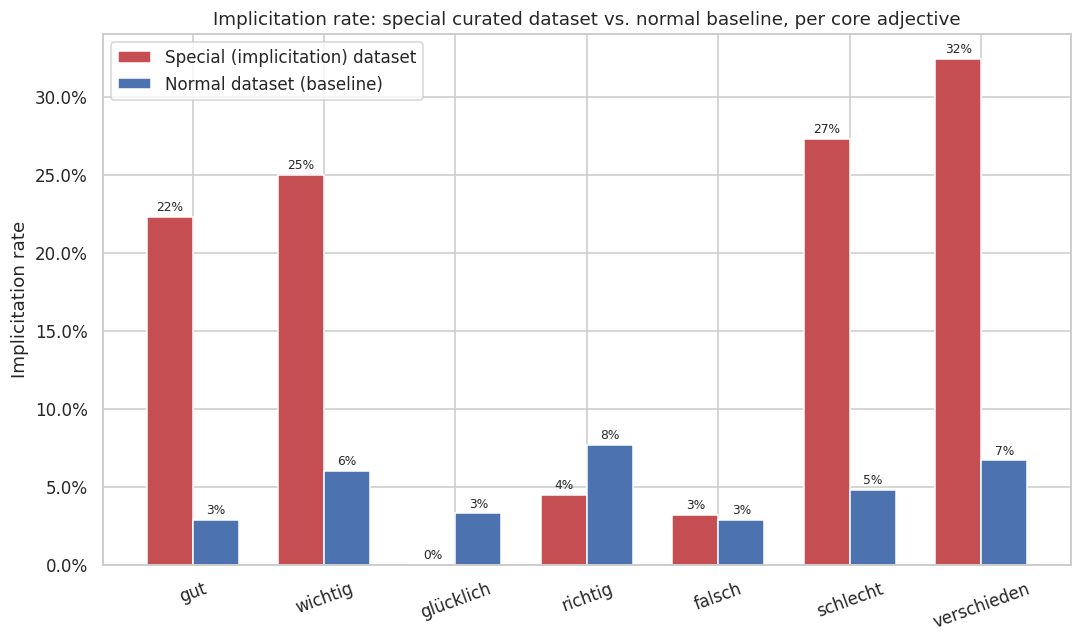

In [ ]:

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(TARGET_ADJECTIVES))
width = 0.35

bars1 = ax.bar(x - width/2, comparison["special_dataset_implicitation_rate"], width,
                label="Special (implicitation) dataset", color="#C44E52")
bars2 = ax.bar(x + width/2, comparison["normal_dataset_implicitation_rate"], width,
                label="Normal dataset (baseline)", color="#4C72B0")

ax.set_xticks(x)
ax.set_xticklabels(TARGET_ADJECTIVES, rotation=20)
ax.set_ylabel("Implicitation rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Implicitation rate: special curated dataset vs. normal baseline, per core adjective")
ax.legend()
ax.bar_label(bars1, fmt="%.0f%%", labels=[f"{v*100:.0f}%" for v in comparison["special_dataset_implicitation_rate"]], padding=2, fontsize=8)
ax.bar_label(bars2, fmt="%.0f%%", labels=[f"{v*100:.0f}%" for v in comparison["normal_dataset_implicitation_rate"]], padding=2, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task18_implicitation_rate_comparison.png"))
plt.show()


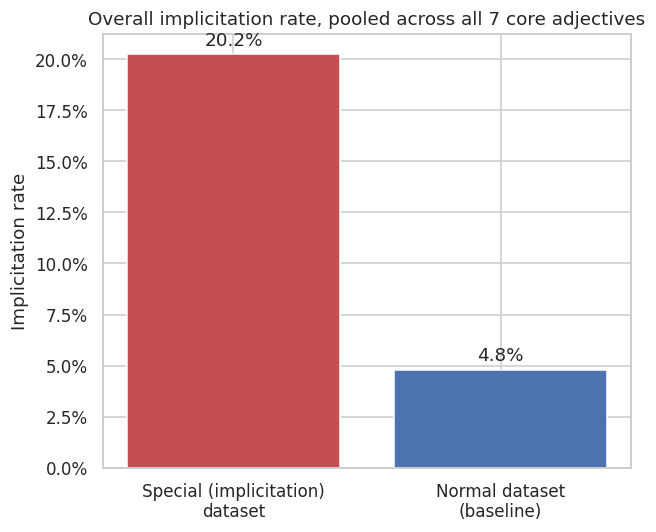

Pooled implicitation rate — special dataset: 20.2%
Pooled implicitation rate — normal dataset:  4.8%


In [ ]:

# Overall (all 7 core adjectives pooled): special vs. normal
overall_special = eff_ct.loc[TARGET_ADJECTIVES, "Implicitation"].sum() / eff_ct.loc[TARGET_ADJECTIVES].sum().sum()
overall_normal = normal_eff_ct.loc[TARGET_ADJECTIVES, "Implicitation"].sum() / normal_eff_ct.loc[TARGET_ADJECTIVES].sum().sum()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["Special (implicitation)\ndataset", "Normal dataset\n(baseline)"],
              [overall_special, overall_normal], color=["#C44E52", "#4C72B0"])
ax.set_ylabel("Implicitation rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Overall implicitation rate, pooled across all 7 core adjectives")
ax.bar_label(bars, fmt="%.1f%%", labels=[f"{overall_special*100:.1f}%", f"{overall_normal*100:.1f}%"], padding=3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task18_overall_comparison.png"))
plt.show()

print(f"Pooled implicitation rate — special dataset: {overall_special*100:.1f}%")
print(f"Pooled implicitation rate — normal dataset:  {overall_normal*100:.1f}%")



## 19. The other 10 English adjectives, for context

The remaining 10 adjectives in this dataset (amazing, beautiful, creative, difficult,
extraordinary, fantastic, fascinating, incredible, interesting, wonderful) are not part of
the core 7 and aren't used in the comparison above, but since we already have the data
loaded, here is their Alteration/Implicitation profile for context — useful if the study
is later extended beyond the 7 core adjectives.


Translationese_effect_,Implicitation,Explicitation,None
source_adjective,,,
interesting,9,1,119
amazing,33,1,89
beautiful,2,1,70
difficult,3,4,58
wonderful,4,0,59
creative,0,0,56
incredible,6,1,46
extraordinary,6,1,29
fascinating,1,0,27


Translationese_effect_,Implicitation,Explicitation,None
source_adjective,,,
interesting,9,1,119
amazing,33,1,89
beautiful,2,1,70
difficult,3,4,58
wonderful,4,0,59
creative,0,0,56
incredible,6,1,46
extraordinary,6,1,29
fascinating,1,0,27


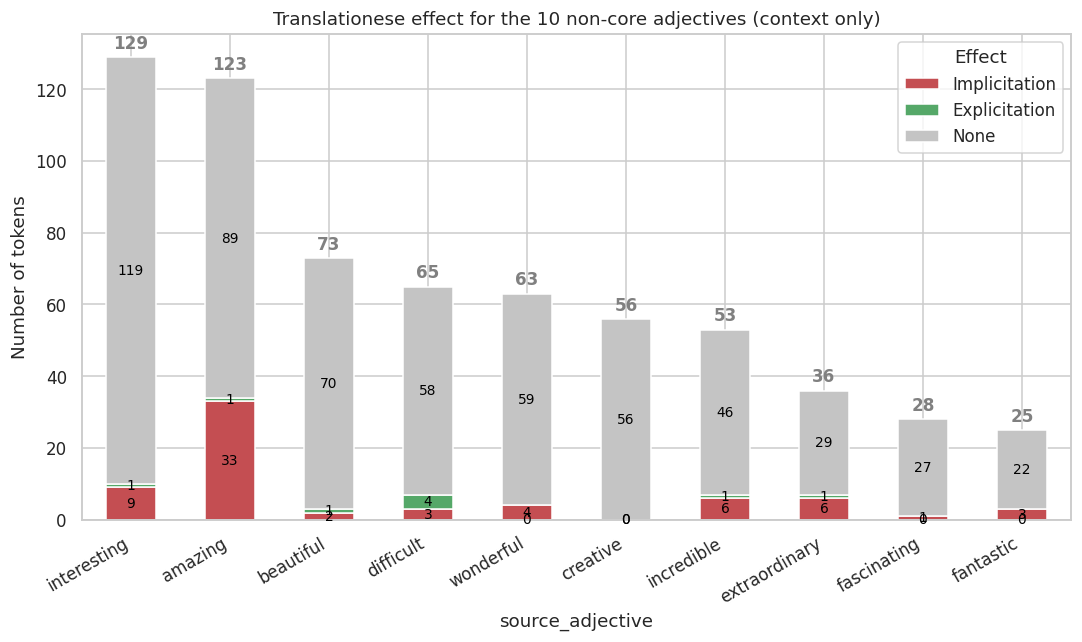

In [ ]:

NON_CORE = [a for a in normal_df_clean["source_adjective"].unique() if a not in CORE_EQUIVALENT_MAP]
NON_CORE = sorted(NON_CORE)

non_core_df = normal_df_clean[normal_df_clean["source_adjective"].isin(NON_CORE)].copy()
non_core_df["Translationese_effect_"] = non_core_df["Translationese_effect"].fillna("None")

non_core_ct = pd.crosstab(non_core_df["source_adjective"], non_core_df["Translationese_effect_"])
for col in ["Implicitation", "Explicitation", "None"]:
    if col not in non_core_ct.columns:
        non_core_ct[col] = 0
non_core_ct = non_core_ct[["Implicitation", "Explicitation", "None"]]
non_core_ct = non_core_ct.loc[non_core_ct.sum(axis=1).sort_values(ascending=False).index]
display(non_core_ct)
non_core_ct.to_csv(os.path.join(OUTPUT_DIR, "task19_non_core_adjectives_effect_counts.csv"))

non_core_prop = non_core_ct.div(non_core_ct.sum(axis=1), axis=0)
non_core_ct = pd.crosstab(
    non_core_df["source_adjective"],
    non_core_df["Translationese_effect_"]
)

for col in ["Implicitation", "Explicitation", "None"]:
    if col not in non_core_ct.columns:
        non_core_ct[col] = 0

non_core_ct = non_core_ct[["Implicitation", "Explicitation", "None"]]

# Sort by total count descending
non_core_ct = non_core_ct.loc[
    non_core_ct.sum(axis=1).sort_values(ascending=False).index
]

display(non_core_ct)

non_core_ct.to_csv(
    os.path.join(OUTPUT_DIR, "task19_non_core_adjectives_effect_counts.csv")
)

# Plot counts instead of proportions
fig, ax = plt.subplots(figsize=(10, 6))

non_core_ct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#C44E52", "#55A868", "#C4C4C4"]
)

ax.set_ylabel("Number of tokens")
ax.set_title("Translationese effect for the 10 non-core adjectives (context only)")

# Add counts inside segments
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",
        fontsize=9,
        color="black"
    )

# Add total count above each bar
totals = non_core_ct.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + max(totals) * 0.01,  # small gap above bar
        str(total),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="gray"
    )

ax.legend(title="Effect", loc="upper right")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "task19_non_core_adjectives_counts.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()